# Schmidt-Weighted Truncation vs. Top-k (Sec. IV, Lemma 2 validation)

Reproduces the comparison between top-k, Schmidt-1cut, Schmidt-3cut, and
random-k truncation, all within the **fixed** Z basis (no BASS rotation is
involved in this section -- it isolates the support-selection question from
the basis-selection question, exactly as in the manuscript's Sec. IV).


In [ ]:
from pathlib import Path
import sys, json
import numpy as np


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for c in (start, *start.parents):
        if (c / "src").is_dir() and (c / "requirements.txt").exists():
            return c
    raise RuntimeError("Repo root not found")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_DIR = REPO_ROOT / "tests" / "results"
FIG_DIR = REPO_ROOT / "tests" / "figures"
DATA_DIR.mkdir(exist_ok=True, parents=True)
FIG_DIR.mkdir(exist_ok=True, parents=True)

from src.simulation.simulator import FixedBasisSimulator
from src.simulation.schmidt_simulator import SchmidtSimulator
from src.experimentation.runner import (
    exact_statevector,
    make_brickwork,
    make_haar,
    paired_comparison_stats,
    build_significance_table,
    format_significance_table,
)
from src.benchmarking.fidelity import compute_fidelity
from src.visualization.style import mplstyle
import matplotlib.pyplot as plt

mplstyle()
print("Imports OK. Repo root:", REPO_ROOT)

Imports OK. Repo root: c:\Users\karti\pyth\BASS


In [ ]:
# ---------------------------------------------------------------------------
# Configuration -- matches Sec. IV.B of the manuscript exactly:
# N = 16, k = 8192, Haar (L=3,5) and 1D brickwork (L=3,5), 100 paired trials.
# ---------------------------------------------------------------------------
QUICK_TEST = False  # flip to True first to sanity-check the pipeline quickly

SEED_BASE = 20260615
N_BOOT = 4000

if QUICK_TEST:
    N = 10
    K = 200
    N_TRIALS = 15
else:
    N = 16
    K = 8192
    N_TRIALS = 100

CONFIGS = {
    "Haar L=3": lambda rng: make_haar(N, depth=3, rng=rng),
    "Haar L=5": lambda rng: make_haar(N, depth=5, rng=rng),
    "Brickwork L=3": lambda rng: make_brickwork(N, depth=3, rng=rng),
    "Brickwork L=5": lambda rng: make_brickwork(N, depth=5, rng=rng),
}

NPZ_PATH = DATA_DIR / (
    "schmidt_truncation_quick.npz" if QUICK_TEST else "schmidt_truncation.npz"
)
META_PATH = NPZ_PATH.with_suffix(".meta.json")
EXPECTED_META = {
    "N": N,
    "K": K,
    "N_TRIALS": N_TRIALS,
    "seed_base": SEED_BASE,
    "configs": list(CONFIGS.keys()),
}
print(f"N={N}, k={K}, N_TRIALS={N_TRIALS}")

N=16, k=8192, N_TRIALS=100


In [3]:
# ---------------------------------------------------------------------------
# Run (or load cached) sweep. Each simulator is instantiated and simulate()'d
# exactly once per trial per method.
# ---------------------------------------------------------------------------
def run_or_load():
    if NPZ_PATH.exists() and META_PATH.exists():
        stored_meta = json.loads(META_PATH.read_text())
        if stored_meta == EXPECTED_META:
            print("Loaded from cache:", NPZ_PATH)
            return dict(np.load(NPZ_PATH, allow_pickle=True))
        print("Cache meta mismatch -- re-running.")

    out = {}
    cfg_names = list(CONFIGS.keys())
    for ci, cfg_name in enumerate(cfg_names):
        gen = CONFIGS[cfg_name]
        f_topk = np.full(N_TRIALS, np.nan)
        f_random = np.full(N_TRIALS, np.nan)
        f_schmidt1 = np.full(N_TRIALS, np.nan)
        f_schmidt3 = np.full(N_TRIALS, np.nan)

        for t in range(N_TRIALS):
            seed = SEED_BASE + ci * 1_000_000 + t
            rng = np.random.default_rng(seed)
            circuit = gen(rng)
            exact_sv = exact_statevector(N, circuit)

            topk_sim = FixedBasisSimulator(N, K, truncation="top-k", verbose=False)
            f_topk[t] = compute_fidelity(topk_sim.simulate(circuit), exact_sv)

            random_sim = FixedBasisSimulator(N, K, truncation="random-k", verbose=False)
            f_random[t] = compute_fidelity(
                random_sim.simulate(circuit, seed=seed), exact_sv
            )

            s1 = SchmidtSimulator(N, K, cut_type="1cut")
            f_schmidt1[t] = s1.simulate(circuit).fidelity(exact_sv)

            s3 = SchmidtSimulator(N, K, cut_type="3cut")
            f_schmidt3[t] = s3.simulate(circuit).fidelity(exact_sv)

        out[f"{cfg_name}||f_topk"] = f_topk
        out[f"{cfg_name}||f_random"] = f_random
        out[f"{cfg_name}||f_schmidt1"] = f_schmidt1
        out[f"{cfg_name}||f_schmidt3"] = f_schmidt3

        gm = lambda a: np.exp(np.mean(np.log(np.clip(a, 1e-300, None))))
        print(
            f"  {cfg_name:16s} GM(top-k)={gm(f_topk):.3e}  GM(random-k)={gm(f_random):.3e}  "
            f"GM(Schmidt-1cut)={gm(f_schmidt1):.3e}  GM(Schmidt-3cut)={gm(f_schmidt3):.3e}"
        )

    np.savez(NPZ_PATH, **out)
    META_PATH.write_text(json.dumps(EXPECTED_META, indent=2))
    print("Saved to", NPZ_PATH)
    return out


data = run_or_load()

  Haar L=3         GM(top-k)=3.040e-01  GM(random-k)=2.011e-01  GM(Schmidt-1cut)=2.744e-01  GM(Schmidt-3cut)=2.822e-01
  Haar L=5         GM(top-k)=4.941e-02  GM(random-k)=2.000e-02  GM(Schmidt-1cut)=3.797e-02  GM(Schmidt-3cut)=3.945e-02
  Brickwork L=3    GM(top-k)=3.408e-01  GM(random-k)=2.290e-01  GM(Schmidt-1cut)=3.137e-01  GM(Schmidt-3cut)=3.227e-01
  Brickwork L=5    GM(top-k)=9.960e-02  GM(random-k)=4.442e-02  GM(Schmidt-1cut)=8.033e-02  GM(Schmidt-3cut)=8.441e-02
Saved to c:\Users\karti\pyth\BASS\tests\results\schmidt_truncation.npz


In [4]:
# ---------------------------------------------------------------------------
# Publication-grade significance table: top-k vs. each competing method,
# H1 = "top-k stochastically dominates the competing method" (Sec. IV.C),
# with a single Holm-Bonferroni correction across all 12 tests
# (4 circuit configs x 3 competing methods).
# ---------------------------------------------------------------------------
records = []
for cfg_name in CONFIGS:
    f_topk = data[f"{cfg_name}||f_topk"]
    for method_name, arr_key in [
        ("Schmidt-1cut", "f_schmidt1"),
        ("Schmidt-3cut", "f_schmidt3"),
        ("random-k", "f_random"),
    ]:
        f_method = data[f"{cfg_name}||{arr_key}"]
        records.append(
            paired_comparison_stats(
                f_topk,
                f_method,
                label=f"{cfg_name}: top-k vs. {method_name}",
                alternative="greater",  # H1: F_top-k > F_method
                n_boot=N_BOOT,
            )
        )

sig_df, sig_meta = build_significance_table(records, alpha=0.05)
print(format_significance_table(sig_df, sig_meta))

csv_path = DATA_DIR / "schmidt_truncation_significance_table.csv"
sig_df.to_csv(csv_path, index=False)
print("\nSaved:", csv_path)

Paired comparisons: 12 tests (holm-bonferroni, family-wise alpha=0.05); 0 skipped (insufficient data)
----------------------------------------------------------------------------------------------------
                                label   n              median_method [IQR]            median_baseline [IQR] GM ratio [95% CI] win rate [Wilson 95% CI]  Wilcoxon p (raw)  Wilcoxon p (Holm)  reject H0  effect size r  n_excluded_zero
     Haar L=3: top-k vs. Schmidt-1cut 100 3.011e-01 [2.594e-01, 3.635e-01] 2.699e-01 [2.292e-01, 3.390e-01]  1.11 [1.1, 1.12]      99/100 [0.95, 1.00]      2.198557e-18       2.337936e-17       True          0.998                0
     Haar L=3: top-k vs. Schmidt-3cut 100 3.011e-01 [2.594e-01, 3.635e-01] 2.799e-01 [2.339e-01, 3.447e-01] 1.08 [1.07, 1.09]      98/100 [0.93, 0.99]      2.133161e-18       2.337936e-17       True          0.999                0
         Haar L=3: top-k vs. random-k 100 3.011e-01 [2.594e-01, 3.635e-01] 1.992e-01 [1.597e-01, 2.545e-

C:\Users\karti\AppData\Local\Temp\ipykernel_18296\4140336029.py:30: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


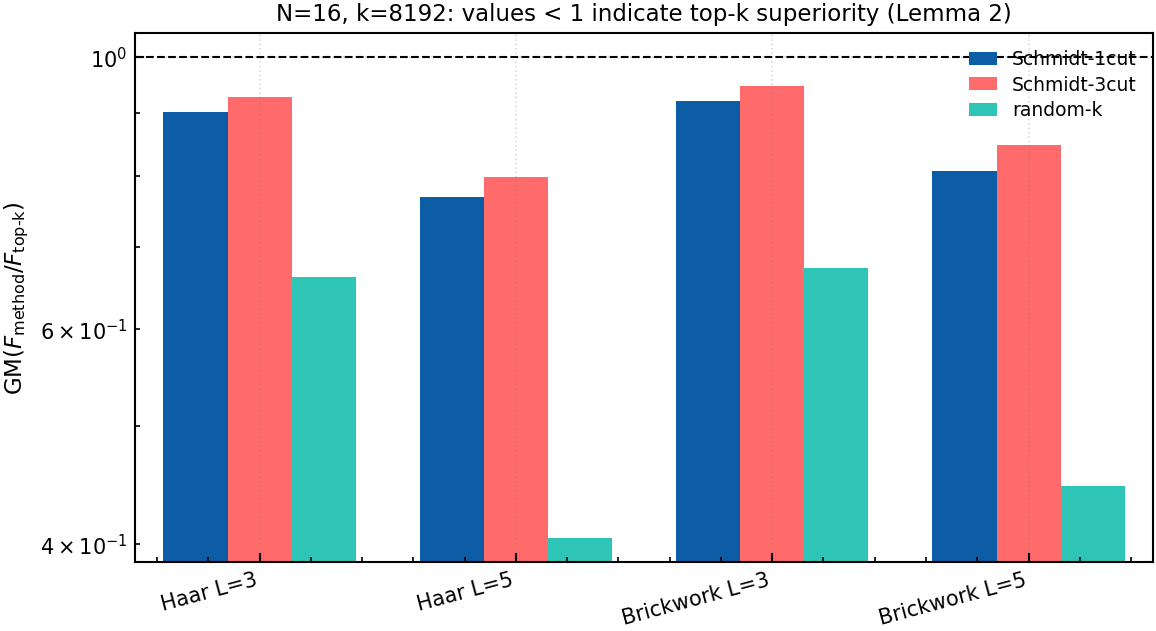

Figure saved.


In [5]:
# ---------------------------------------------------------------------------
# Ratio bar chart: GM(F_method / F_top-k) per config, per competing method
# (values < 1 indicate top-k superiority, matching Lemma 2's prediction).
# ---------------------------------------------------------------------------
cfg_names = list(CONFIGS.keys())
methods = ["Schmidt-1cut", "Schmidt-3cut", "random-k"]
x = np.arange(len(cfg_names))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 4.5))

for i, method_name in enumerate(methods):
    ratios = []
    for cfg_name in cfg_names:
        row = sig_df.loc[
            sig_df["label"] == f"{cfg_name}: top-k vs. {method_name}"
        ].iloc[0]
        # row's ratio_gm is F_topk / F_method (method=top-k, baseline=competitor);
        # invert to plot F_method / F_topk so values < 1 = top-k wins, matching
        # the manuscript's Table II/III convention.
        ratios.append(1.0 / row["_ratio_gm"])
    ax.bar(x + (i - 1) * width, ratios, width, label=method_name)

ax.axhline(1.0, color="k", lw=1, ls="--")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(cfg_names, rotation=15, ha="right")
ax.set_ylabel(r"GM($F_\mathrm{method} / F_\mathrm{top\text{-}k}$)")
ax.set_title(f"N={N}, k={K}: values < 1 indicate top-k superiority (Lemma 2)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_schmidt_truncation_ratio.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_schmidt_truncation_ratio.png", dpi=200, bbox_inches="tight")
plt.show()
print("Figure saved.")

**Manuscript note:** Tables II–III's per-cell Wilcoxon p-values and win
rates should now cite `sig_df`
(`tests/results/schmidt_truncation_significance_table.csv`), which reports
the Holm-corrected p-value across the full 12-test family and the rank-
biserial effect size alongside each existing ratio/win-rate/p-value already
in the manuscript.
